#Chapter 6. 합성곱 신경망 II - Part 1(~6.1.4)

##6.1 이미지 분류를 위한 신경망

###6.1.1 LeNet-5

In [ ]:
!pip install --user tqdm

In [ ]:
#코드 6-1. 필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms #이미지 변환(전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim #경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os #파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm #진행 상황을 가시적으로 표현해주는데,
                                       #특히 모델의 학습 경과를 확인하고 싶을 때 사용하는 라이브러리
import random
from matplotlib import pyplot as plt

#파이토치는 텐서플로와 다르게 GPU를 자동으로 할당X,GPU 할당을 모델과 데이터에 선언
#단 이장에서는 CPU사용
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#코드 6-2. 이미지 데이터셋 전처리
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [ ]:
#코드 6-3. 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리
cat_directory = r'/content/drive/MyDrive/Euron9_DL/data/dogs-vs-cats/Cat'
dog_directory = r'/content/drive/MyDrive/Euron9_DL/data/dogs-vs-cats/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] #개와 고양이 이미지들을 합쳐 저장
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] #훈련용 400개 이미지
val_images_filepaths = correct_images_filepaths[400:-10] #검증용 92개 이미지
test_images_filepaths = correct_images_filepaths[-10:] #테스트용 10개 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [ ]:
#코드 6-4. 테스트 데이터셋 이미지 확인 함수
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
  rows = len(images_filepaths) // cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
    predicted_label = predicted_labels[i] if predicted_labels else true_label
    #예측과 정답(레이블)이 동일하면 초록색, 그렇지 않으면 빨간색으로 표시
    color = "green" if true_label == predicted_label else "red"
    ax.ravel()[i].imshow(image) #개별 이미지를 출력
    ax.ravel()[i].set_title(predicted_label, color=color) #predicted_label을 타이틀로 사용
    ax.ravel()[i].set_axis_off() #이미지의 축 제거
  plt.tight_layout() #이미지의 여백을 조정
  plt.show()

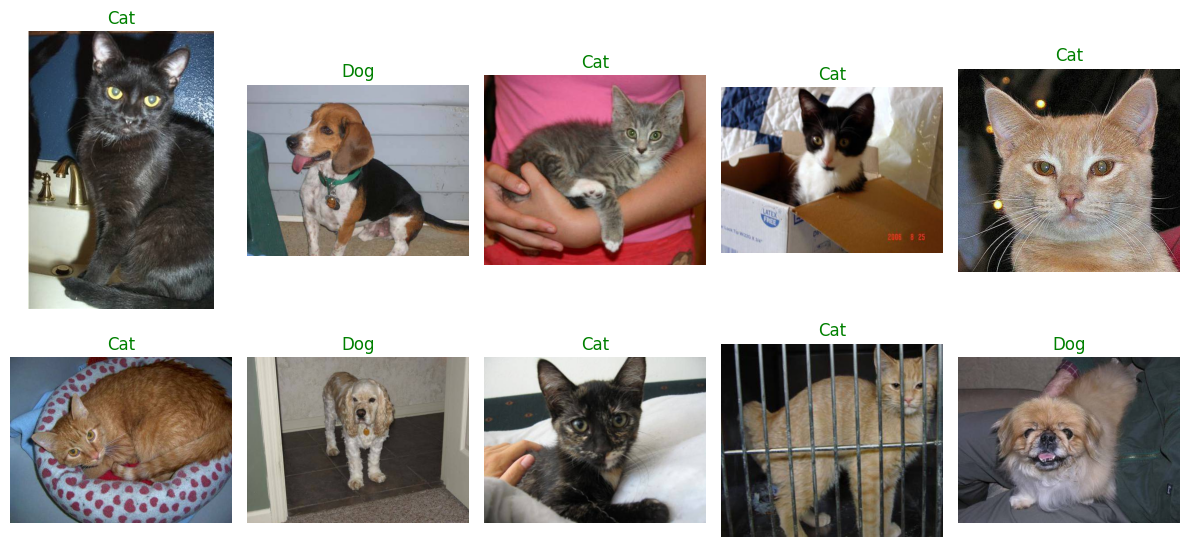

In [ ]:
#코드 6-5. 테스트 데이터셋 이미지를 출력
display_image_grid(test_images_filepaths)

In [ ]:
#코드 6-6. 이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'): #데이터셋의 전처리(데이터 변형 적용)
    self.file_list = file_list
    self.transform = transform #클래스 호출할 때 transform에 대한 매개변수를 받아옴
    self.phase = phase #'train'적용

  def __len__(self): #images_filepaths 데이터셋의 전체 길이를 반환
    return len(self.file_list)

  def __getitem__(self, idx): #데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태
    img_path = self.file_list[idx]
    img = Image.open(img_path) #img_path위치에서 이미지 데이터들을 가져옴
    img_transformed = self.transform(img, self.phase) #이미지에 'train'전처리를 사용
    label = img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label

In [ ]:
#코드 6-7. 변수 값 정의
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [ ]:
#코드 6-8. 이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size,
                mean, std), phase='train') #훈련 이미지에 train_transform를 적용
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
              mean, std), phase='val') #검증 이미지에 test_transform를 적용
index = 0
print(train_dataset.__getitem__(index)[0].size()) #훈련 데이터의 크기 출력
print(train_dataset.__getitem__(index)[1]) #훈련 데이터의 레이블 출력

torch.Size([3, 224, 224])
0


In [ ]:
#코드 6-9. 데이터로더 정의
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val':val_dataloader} #훈련 데이터셋과 검증 데이터셋을 합쳐서 표현

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 1, 1, 1, 1, 0, 0])


In [ ]:
#코드 6-10. 모델의 네트워크 클래스
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    #2D 합성곱층 적용,입력 형태는 (3,224,224),출력 형태는 (w-k_s+1)/stride에 따라 (16,220,220)
    self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1,
                          padding=0)
    self.relu1 = nn.ReLU() #ReLU 활성화 함수
    #최대 풀링 적용, 적용 이후 출력 형태는 220/2가 되어 (16, 110, 110)
    self.maxpool1 = nn.MaxPool2d(kernel_size=2)
    #또다시 2D 합성곱층 적용, 출력 형태는(32,106,106)
    self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5,
                          stride=1, padding=0)
    self.relu2 = nn.ReLU()
    #최대 풀링 적용, 출력 형태는 (32,53,53)
    self.maxpool2 = nn.MaxPool2d(kernel_size=2)

    self.fc1 = nn.Linear(32*53*53, 512)
    self.relu5 = nn.ReLU()
    self.fc2 = nn.Linear(512,2)
    self.output = nn.Softmax(dim=1)

  def forward(self, x):
    out = self.cnn1(x)
    out = self.relu1(out)
    out = self.maxpool1(out)
    out = self.cnn2(out)
    out = self.relu2(out)
    out = self.maxpool2(out)
    out = out.view(out.size(0), -1) #완전연결층에 데이터를 전달하기 위해 1차원으로 변형
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.output(out)
    return out

In [ ]:
#코드 6-11. 모델 객체 생성
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [ ]:
!pip install torchsummary

In [ ]:
#코드 6-12. torchsummary 라이브러리를 이용한 모델의 네트워크 구조 확인
from torchsummary import summary
summary(model, input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [ ]:
#코드 6-13. 학습 가능한 파라미터 수 확인
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


In [ ]:
#코드 6-14. 옵티마이저와 손실 함수 정의
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
#코드 6-15. 모델의 파라미터와 손실 함수를 CPU에 할당
model = model.to(device)
criterion = criterion.to(device)

In [ ]:
#코드 6-16. 모델 학습 함수 정의
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since = time.time()
  best_acc = 0.0

  for epoch in range(num_epoch): #epoch를 10으로 설정했으므로 10회 반복
    print('Epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in ['train','val']:
      if phase == 'train':
        model.train() #모델을 학습시키겠다는 의미
      else:
        model.eval()

      epoch_loss = 0.0
      epoch_corrects = 0

      #여기서 dataloader_dict는 훈련 데이터셋을 의미
      for inputs, labels in tqdm(dataloader_dict[phase]):
        inputs = inputs.to(device) #훈련 데이터셋을 CPU에 할당
        labels = labels.to(device)
        optimizer.zero_grad() #역전파 단계를 실행하기 전에 기울기를 0으로 초기화

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs,1)
          loss = criterion(outputs, labels) #손실 함수를 이용한 오차 계산

          if phase == 'train':
            loss.backward() #모델의 학습 가능한 모든 파라미터에 대해 기울기를 계산
            optimizer.step() #optimizer의 step함수를 호출하면 파라미터 갱신
          epoch_loss += loss.item() * inputs.size(0)
          #정답과 예측이 일치하면 그것의 합계를 epoch_corrects에 저장
          epoch_corrects += torch.sum(preds == labels.data)
      epoch_loss = epoch_loss/len(dataloader_dict[phase].dataset) #최종 오차계산
      epoch_acc = epoch_corrects.double()/len(dataloader_dict[phase].dataset) #최종 정확도

      print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

      if phase == 'val' and epoch_acc>best_acc: #검증 데이터셋에 대한 가장 최적의 정확도 저장
        best_acc = epoch_acc
        best_model_wts = model.state_dict()

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,
                                                         time_elapsed%60))
  print('Best val Acc: {:.4f}'.format(best_acc))
  return model

In [ ]:
#코드 6-17. 모델 학습
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipython-input-3336776232.py:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6885 Acc: 0.5525


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6842 Acc: 0.6087
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6574 Acc: 0.6100


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6648 Acc: 0.5978
Training complete in 7m 44s
Best val Acc: 0.6087


In [ ]:
#코드 6-18. 모델 테스트를 위한 함수 정의
import pandas as pd

id_list = []
pred_list = []
# 역전파 중 텐서들에 대한 변화도를 계산할 필요가 없음을 나타내는 것으로,
# 훈련 데이터셋의 모델 학습과 가장 큰 차이점
with torch.no_grad():
  for test_path in tqdm(test_images_filepaths): #테스트 데이터셋 이용
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean, std)
    img = transform(img, phase = 'val') #테스트 데이터셋 전처리 적용
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs, dim=1)[:,1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])
res = pd.DataFrame({
    'id':id_list,
    'label':pred_list
}) #테스트 데이터셋의 예측 결과인 id와 레이블을 데이터 프레임에 저장
res.sort_values(by='id',inplace=True)
res.reset_index(drop=True, inplace=True)
res.to_csv('/content/drive/MyDrive/Euron9_DL/data/LeNet',index=False)

/tmp/ipython-input-2582567914.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): #테스트 데이터셋 이용


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
#코드 6-19. 테스트 데이터셋의 예측 결과 호출
res.head(10)

,id,label
0,109,0.444622
1,145,0.388103
2,15,0.609328
3,162,0.431105
4,167,0.512944
5,200,0.302237
6,210,0.474873
7,211,0.532126
8,213,0.359908
9,224,0.579990


In [ ]:
#코드 6-20. 테스트 데이터셋 이미지를 출력하기 위한 함수 정의
class_ = classes = {0:'cat',1:'dog'} #개와 고양이에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(),cols=5):
  rows = len(images_filepaths) // cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    a=random.choice(res['id'].values) #데이터 프레임의 id라는 칼럼에서 임의로 데이터 가져오기
    label = res.loc[res['id'] == a, 'label'].values[0]
    if label > 0.5: #레이블 값이 0.5보다 크면 개
      label = 1
    else: #레이블 값이 0.5보다 작다면 고야이
      label = 0
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

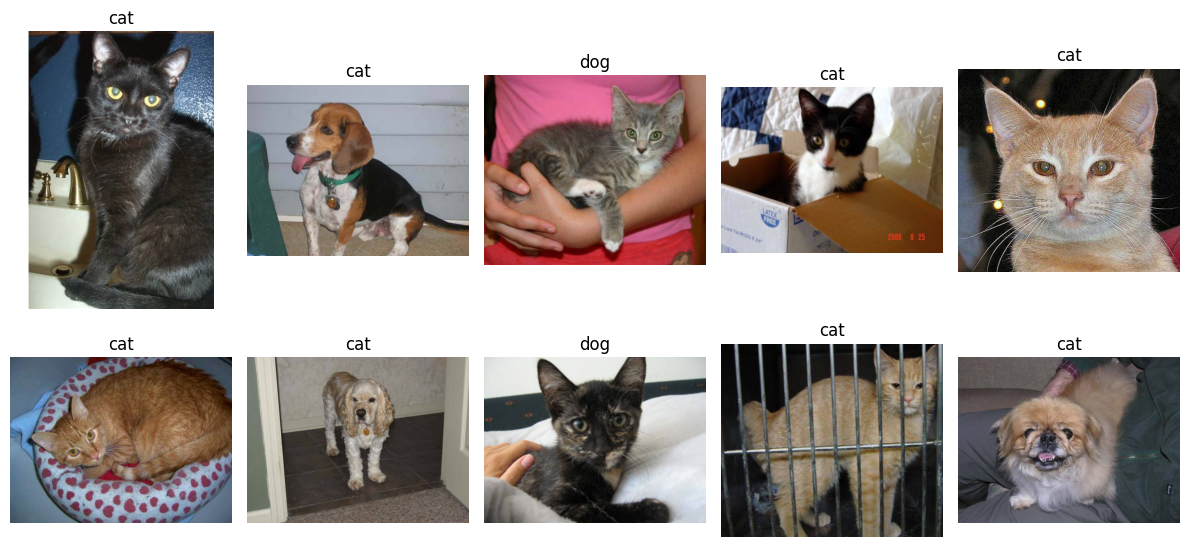

In [ ]:
#코드 6-21. 테스트 데이터셋 예측 결과 이미지 출력
display_image_grid(test_images_filepaths)

- 일부 데이터만 사용했기에 예측력이 좋진 않음
- 데이터 전체 사용시, 성능 향상 기대

###6.1.2 AlexNet

In [ ]:
#코드 6-22. 필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms #이미지 변환(전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim #경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os #파일 경로에 대한 함수들을 제공
import cv2
import random
from PIL import Image
from tqdm import tqdm_notebook as tqdm #진행 상황을 가시적으로 표현해주는데,
                                       #특히 모델의 학습 경과를 확인하고 싶을 때 사용하는 라이브러리

#파이토치는 텐서플로와 다르게 GPU를 자동으로 할당X,GPU 할당을 모델과 데이터에 선언
#단 이장에서는 CPU사용
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#코드 6-23. 이미지 데이터셋 전처리
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [ ]:
#코드 6-24. 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리
cat_directory = r'/content/drive/MyDrive/Euron9_DL/data/dogs-vs-cats/Cat'
dog_directory = r'/content/drive/MyDrive/Euron9_DL/data/dogs-vs-cats/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                               os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] #개와 고양이 이미지들을 합쳐 저장
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] #훈련용 400개 이미지
val_images_filepaths = correct_images_filepaths[400:-10] #검증용 92개 이미지
test_images_filepaths = correct_images_filepaths[-10:] #테스트용 10개 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [ ]:
#코드 6-25. 커스텀 데이터셋 정의
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'): #데이터셋의 전처리(데이터 변형 적용)
    self.file_list = file_list #이미지 데이터가 위치한 파일 경로
    self.transform = transform #이미지 데이터 전처리
    self.phase = phase #self.phase는 ImageTransform()에서 정의한 'train','val'을 의미

  def __len__(self): #images_filepaths 데이터셋의 전체 길이를 반환
    return len(self.file_list)

  def __getitem__(self, idx): #데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태
    img_path = self.file_list[idx] #이미지 데이터의 인덱스 가져오기
    img = Image.open(img_path) #img_path위치에서 이미지 데이터들을 가져옴
    img_transformed = self.transform(img, self.phase) #이미지에 'train'전처리를 사용

    label = img_path.split('/')[-1].split('.')[0] #레이블 값을 가져오기
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label #전처리가 적용된 이미지와 레이블 반환

In [ ]:
#코드 6-26. 변수 값 정의
#AlexNet은 깊이가 깊은 네트워크를 사용하므로 이미지 크기가 256이 아니면
#풀링층 때문에 크기가 계속 줄어들어 오류가 발생할 수 있음
size = 226
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [ ]:
#코드 6-27. 훈련, 검증, 테스트 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size,
                mean, std), phase='train') #훈련 이미지에 train_transform를 적용
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
              mean, std), phase='val') #검증 이미지에 test_transform를 적용
test_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
               mean, std), phase='val')
index = 0
print(train_dataset.__getitem__(index)[0].size()) #훈련 데이터의 크기 출력
print(train_dataset.__getitem__(index)[1]) #훈련 데이터의 레이블 출력

torch.Size([3, 226, 226])
0


In [ ]:
#코드 6-28. 데이터셋을 메모리로 불러옴
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val':val_dataloader}


batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 226, 226])
tensor([0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
        1, 0, 0, 1, 0, 1, 1, 1])


In [ ]:
#코드 6-29. AlexNet 모델 네트워크 정의
class AlexNet(nn.Module):
  def __init__(self) -> None:
    super(AlexNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3,64,kernel_size=11, stride=4, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(64,192,kernel_size=5,padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(192,384,kernel_size=3,padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(384, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.avgpool = nn.AdaptiveAvgPool2d((6,6))
    self.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(256*6*6,4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096,512),
        nn.ReLU(inplace=True),
        nn.Linear(512,2),
    )

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    x=self.features(x)
    x=self.avgpool(x)
    x=torch.flatten(x,1)
    x=self.classifier(x)
    return x

In [ ]:
#코드 6-30. model 객체 생성
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
#코드 6-31. 옵티마이저 및 손실 함수 정의
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
#코드 6-32. 모델 네트워크 구조 확인
from torchsummary import summary
summary(model, input_size=(3,226,226))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
AdaptiveAvgPool2d-14            [-1, 25

In [ ]:
#코드 6-33. 모델 학습 함수 정의
import time

def train_model(model,dataloader_dict,criterion,optimizer,num_epoch):

  since = time.time()
  best_acc=0.0

  for epoch in range(num_epoch):
    print('Epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in ['train','val']:
      if phase == 'train':
        model.train()
      else:
        model.eval()

      epoch_loss=0.0
      epoch_corrects = 0

      for inputs, labels in tqdm(dataloader_dict[phase]):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(phase=='train'):
          outputs=model(inputs)
          _, preds = torch.max(outputs,1)
          loss = criterion(outputs,labels)

          if phase == 'train':
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item() * inputs.size(0)
        epoch_corrects += torch.sum(preds==labels.data)

      epoch_loss = epoch_loss/len(dataloader_dict[phase].dataset)
      epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

      print('{} Loss: {:.4f} Acc:{:.4f}'.format(phase, epoch_loss,epoch_acc))

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,
                                                        time_elapsed%60))
  return model

In [ ]:
#코드 6-34. 모델 학습
num_epoch=10
model=train_model(model,dataloader_dict,criterion,optimizer,num_epoch)

Epoch 1/10
--------------------


/tmp/ipython-input-3454284059.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6935 Acc:0.5025


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6932 Acc:0.5109
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6932 Acc:0.5025


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6932 Acc:0.5109
Training complete in 8m 37s


In [ ]:
#코드 6-35. 모델을 이용한 예측
import pandas as pd
id_list = []
pred_list = []
_id = 0
with torch.no_grad():
  for test_path in tqdm(test_images_filepaths): #테스트 이미지 데이터 이용
    img = Image.open(test_path)
    #이미지 데이터 번호 가져오기(예: dog.113.jpg라는 이미지 이름에서 113가져오기)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean, std)
    img = transform(img, phase = 'val') #테스트 데이터에 검증용 전처리 적용
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs, dim=1)[:,1].tolist()

    id_list.append(_id)
    pred_list.append(preds[0])

res = pd.DataFrame({
    'id':id_list,
    'label':pred_list
}) #데이터 프레임에 이미지의 id(번호)와 레이블 저장
#이미지의 id와 레이블을 alexnet.csv파일에 저장
res.to_csv('/content/drive/MyDrive/Euron9_DL/data/alexnet.csv',index=False)

/tmp/ipython-input-926145447.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): #테스트 이미지 데이터 이용


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
#코드 6-36. 데이터 프레임 결과 확인
res.head(10)

,id,label
0,145,0.508382
1,211,0.508783
2,162,0.509021
3,200,0.508354
4,210,0.508880
5,224,0.509199
6,213,0.509039
7,109,0.508674
8,15,0.508717
9,167,0.509274


In [ ]:
#코드 6-37. 예측 결과를 시각적으로 표현하기 위한 함수 정의
class_ = classes = {0:'cat',1:'dog'} #개와 고양이에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(),cols=5):
  rows = len(images_filepaths) // cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    a=random.choice(res['id'].values) #데이터 프레임의 id라는 칼럼에서 임의로 데이터 가져오기
    label = res.loc[res['id'] == a, 'label'].values[0]
    if label > 0.5: #레이블 값이 0.5보다 크면 개
      label = 1
    else: #레이블 값이 0.5보다 작다면 고야이
      label = 0
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

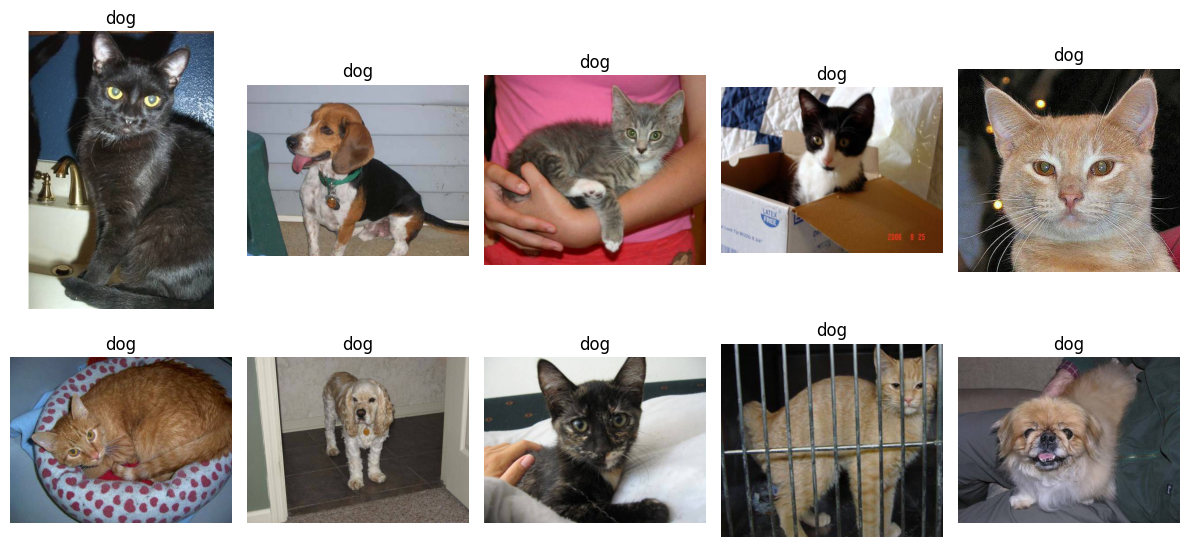

In [ ]:
#코드 6-38. 예측 결과에 대해 이미지와 함께 출력
display_image_grid(test_images_filepaths)

- 예측 결과가 좋지 않지만, 데이터셋이 많으면 성능이 좋아질 수 있음

###6.1.3 VGGNet

In [ ]:
#코드 6-39. 필요한 라이브러리 호출
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#코드 6-40. VGG 모델 정의
class VGG(nn.Module):
  def __init__(self,features,output_dim):
    super().__init__()
    self.features = features #VGG모델에 대한 매개변수에서 받아 온 features값을 self.features에 넣어줌
    self.avgpool = nn.AdaptiveAvgPool2d(7)
    self.classifier = nn.Sequential(
        nn.Linear(512*7*7,4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096,4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096,output_dim)
    ) #완전연결층과 출력층 정의
  def forward(self,x):
    x=self.features(x)
    x=self.avgpool(x)
    h=x.view(x.shape[0],-1)
    x=self.classifier(h)
    return x,h

In [ ]:
#코드 6-41. 모델 유형 정의
#8(합성곱층)+3(풀링층)=11(전체계층)=VGG11
vgg11_config = [64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M']
#10(합성곱층)+3(풀링층)=13(전체계층)=VGG13
vgg13_config=[64,64,'M',128,128,'M',256,256,'M',512,512,'M',512,512,'M']
#13(합성곱층)+3(풀링층)=16(전체계층)=VGG16
vgg16_config=[64,64,'M',128,128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M']
#16(합성곱층)+3(풀링층)=19(전쳬계층)=VGG19
vgg19_config = [64,64,'M',128,128,'M',256,256,256,256,'M',512,512,512,512,'M',512,512,512,512,'M']

In [ ]:
#코드 6-42. VGG계층 정의
def get_vgg_layers(config,batch_norm):
  layers=[]
  in_channels=3

  for c in config: #vgg11_config값들을 가져옵니다
    assert c == 'M' or isinstance(c,int)
    if c == 'M': #불러온 값이 M이면 최대풀링(MaxPool2d)을 적용
      layers += [nn.MaxPool2d(kernel_size=2)]
    else: #불러온 값이 숫자이면 합성곱(Conv2d)적용
      conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding=1)
      if batch_norm: #배치 정규화(batch_normalization)를 적용할지에 대한 코드
        #배치 정규화가 적용될 경우 배치정규화+ReLU 적용
        layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
      #배치 정규화가 적용되지 않을 경우 ReLU만 적용
      else:
        layers += [conv2d,nn.ReLU(inplace=True)]
      in_channels = c

  return nn.Sequential(*layers) #네트워크의 모든 계층을 반환

In [ ]:
#코드 6-43. 모델 계층 생성
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)

In [ ]:
#코드 6-44. VGG11계층 확인
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [ ]:
#코드 6-45. VGG11 전체에 대한 네트워크
OUTPUT_DIM = 2 #개와 고양이 두 개의 클래스 사용
model = VGG(vgg11_layers,OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [ ]:
#코드 6-46. VGG11 사전 훈련된 모델 사용
import torchvision.models as models
pretrained_model = models.vgg11_bn(pretrained=True)
print(pretrained_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [ ]:
#코드 6-47. 이미지 데이터 전처리
train_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [ ]:
#코드 6-48. ImageFolder를 이용하여 데이터셋 불러오기
train_path ='/content/drive/MyDrive/Euron9_DL/data/catanddog/train'
test_path='/content/drive/MyDrive/Euron9_DL/data/catanddog/test'

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)
test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

In [ ]:
#코드 6-49. 훈련과 검증 데이터 분할
VALID_RATIO = 0.9
#전체 훈련 데이터 중 90%를 훈련 데이터셋으로 사용
n_train_examples = int(len(train_dataset)*VALID_RATIO)
#전체 훈련 데이터 중 10%를 검증 데이터셋으로 사용
n_valid_examples = len(train_dataset)-n_train_examples

train_data, valid_data = data.random_split(
    train_dataset,[n_train_examples,n_valid_examples])

In [ ]:
#코드 6-50. 검증 데이터 전처리
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [ ]:
#코드 6-51. 훈련, 검증, 테스트 데이터셋 수 확인
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 476
Number of validation examples: 53
Number of testing examples: 12


In [ ]:
#코드 6-52. 메모리로 데이터 불러오기
BATCH_SIZE = 64
train_iterator = data.DataLoader(
    train_data, shuffle=True, batch_size=BATCH_SIZE) #훈련 데이터셋은 임의로 섞어서 가져옴

valid_iterator = data.DataLoader(valid_data, batch_size=BATCH_SIZE)
test_iterator = data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
#코드 6-53. 옵티마이저와 손실 함수 정의
optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [ ]:
#코드 6-54. 모델 정확도 측정 함수
def calculate_accuracy(y_pred,y):
  top_pred = y_pred.argmax(1,keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float() / y.shape[0]
  return acc

In [ ]:
#코드 6-55. 모델 학습 함수 정의
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.train()

  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred, _ = model(x)
    loss = criterion(y_pred,y)
    acc = calculate_accuracy(y_pred,y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc += acc.item()

  return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
#6-56. 모델 성능 측정 함수
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.eval()
  with torch.no_grad():
    for (x,y) in iterator:
      x=x.to(device)
      y=y.to(device)
      y_pred, _ = model(x)
      loss = criterion(y_pred,y)
      acc = calculate_accuracy(y_pred,y)
      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
#코드 6-57. 학습 시간 측정 함수
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time / 60)
  elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
  return elapsed_mins, elapsed_secs

In [ ]:
#코드 6-58. 모델 학습
import time
EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS):
  start_time = time.monotonic()
  #훈련 데이터셋을 모델에 적용한 결과(오차와 정확도)를 train_loss와 train_acc에 저장
  train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
  #검증 데이터셋을 모델에 적용한 결과(오차와 정확도)를 valid_loss와 valid_acc에 저장
  valid_loss, valid_acc = evaluate(model, valid_iterator,criterion, device)

  #valid_loss가 가장 작은 값을 구하고 그 상태의 모델을 VGG-model.pt이름으로 저장
  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '/content/drive/MyDrive/Euron9_DL/data/VGG-model.pt')

  end_time = time.monotonic()
  #모델 훈련에 대한 시작과 종료 시간을 저장
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
  print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 11m 57s
	Train Loss: 0.693 | Train Acc: 54.72%
	 Val. Loss: 0.699 |  Val. Acc: 45.28%
Epoch: 02 | Epoch Time: 11m 54s
	Train Loss: 0.694 | Train Acc: 53.46%
	 Val. Loss: 0.701 |  Val. Acc: 45.28%
Epoch: 03 | Epoch Time: 11m 41s
	Train Loss: 0.705 | Train Acc: 50.20%
	 Val. Loss: 0.696 |  Val. Acc: 49.06%
Epoch: 04 | Epoch Time: 11m 58s
	Train Loss: 0.696 | Train Acc: 50.22%
	 Val. Loss: 0.689 |  Val. Acc: 56.60%
Epoch: 05 | Epoch Time: 12m 1s
	Train Loss: 0.696 | Train Acc: 51.67%
	 Val. Loss: 0.686 |  Val. Acc: 54.72%


- 성능이 좋지 않음

  -> 데이터셋의 이미지 수가 매우 적으며, 에포크도 적게 설정 돼있음

In [ ]:
#코드 6-59. 테스트 데이터셋을 이용한 모델 성능 측정
model.load_state_dict(torch.load('/content/drive/MyDrive/Euron9_DL/data/VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.687 | Test Acc: 41.67%


In [ ]:
#코드 6-60. 테스트 데이터셋을 이용한 모델의 예측 확인 함수
def get_predictions(model, iterator):
  model.eval()
  images=[]
  labels=[]
  probs=[]

  with torch.no_grad():
    for (x,y) in iterator:
      x=x.to(device)
      y_pred,_ =model(x)
      y_prob = F.softmax(y_pred,dim=1)
      top_pred = y_prob.argmax(1,keepdim=True)
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())

  images = torch.cat(images, dim=0)
  labels = torch.cat(labels,dim=0)
  probs = torch.cat(probs,dim=0)
  return images, labels, probs

In [ ]:
#코드 6-61. 예측 중에서 정확하게 예측한 것을 추출
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs,1)
corrects = torch.eq(labels,pred_labels)
correct_examples=[]

for image, label, prob, correct in zip(images,labels,probs,corrects):
  if not correct:
    correct_examples.append((image,label,prob))

correct_examples.sort(reverse=True, key=lambda x:torch.max(x[2], dim=0).values)

In [ ]:
#코드 6-62. 이미지 출력을 위한 전처리
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min=image_min, max=image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

In [ ]:
#코드 6-63. 모델이 정확하게 예측한 이미지 출력 함수
def plot_most_correct(correct, classes, n_images, normalize = True):
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize = (25, 20))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)
        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0)
        true_prob = probs[true_label]
        correct_prob, correct_label = torch.max(probs, dim = 0)
        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' \
                     f'pred label: {correct_class} ({correct_prob:.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace = 0.4)

In [ ]:
import matplotlib.pyplot as plt

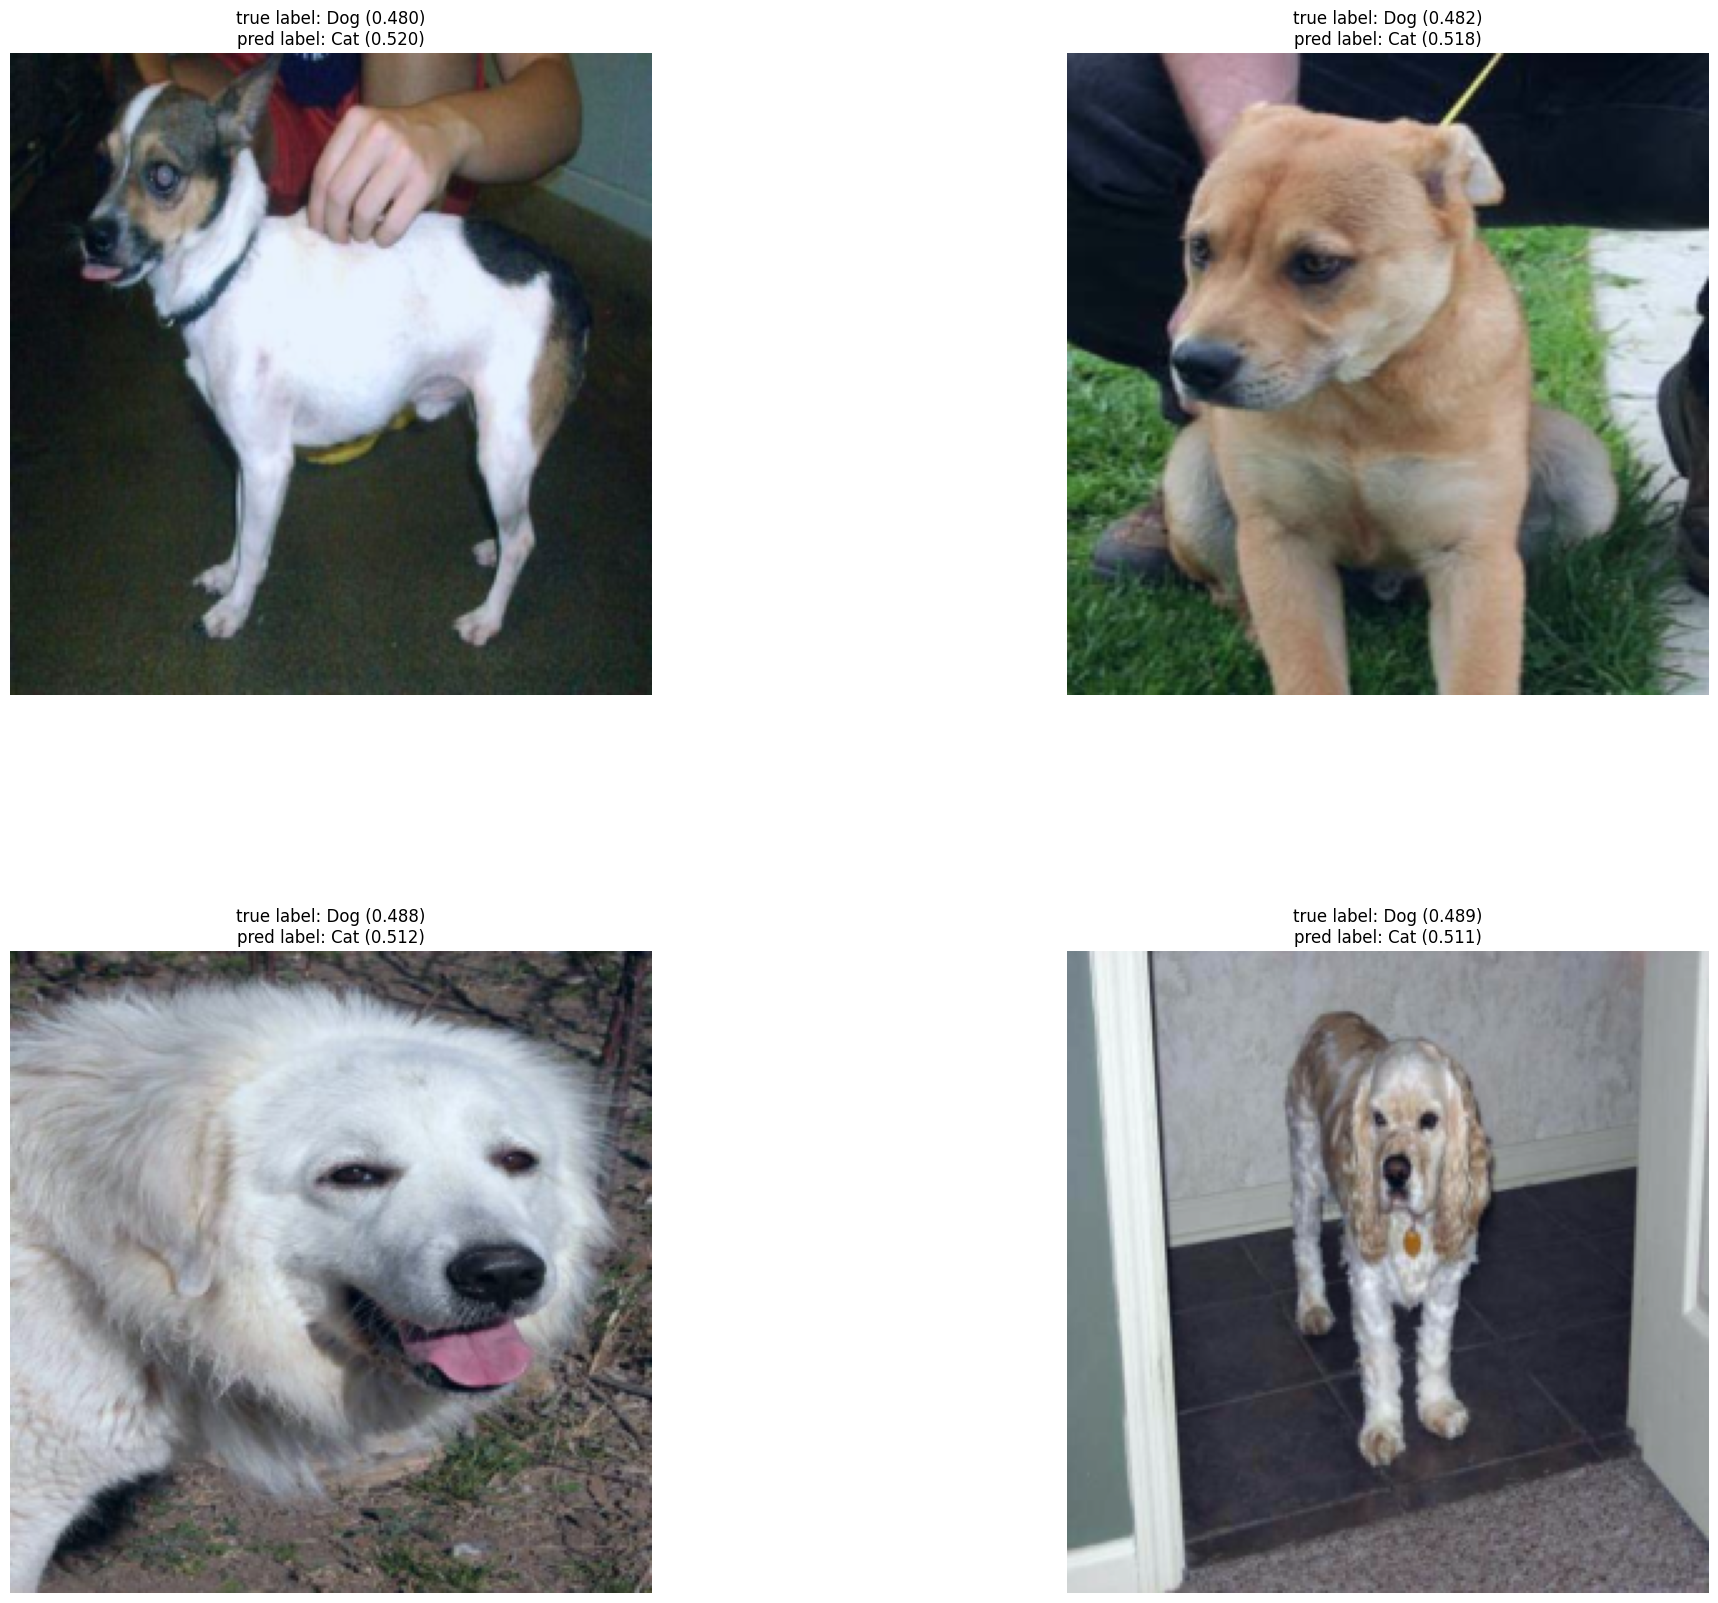

In [ ]:
#코드 6-64. 예측 결과 이미지 출력
classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)